# What the Hell
Something is wrong with my pipeline -> Current theories is something to do with PCA or with activation extraction

In [8]:
import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt

import sys      
sys.path.insert(0, "/storage/project/r-aivanova7-0/shared/eyas/geometry_of_truth_replication")
from src.activations import load_acts


In [9]:
acts_original = load_acts(            
  model_name="llama-2-13b",
  dataset_name="cities",   
  layer=15,   
  output_dir="/storage/home/hcoda1/7/eayesh3/scratch/geometry_of_truth/acts_original",              
  center=True,
) 

acts_rightpad = load_acts(            
  model_name="llama-2-13b",
  dataset_name="cities",   
  layer=15,   
  output_dir="/storage/home/hcoda1/7/eayesh3/scratch/geometry_of_truth/acts_rightpad",              
  center=True,
) 

In [10]:
acts_precise = load_acts(            
  model_name="llama-2-13b",
  dataset_name="cities",   
  layer=15,   
  output_dir="/storage/home/hcoda1/7/eayesh3/scratch/geometry_of_truth/acts_precise",              
  center=False,
) 

In [21]:
acts_leftpad = load_acts(            
  model_name="llama-2-13b",
  dataset_name="cities",   
  layer=15,   
  output_dir="/storage/home/hcoda1/7/eayesh3/scratch/geometry_of_truth/acts",              
  center=True,
) 

In [22]:
# convert to tensors if needed
acts_original = torch.tensor(acts_original)
acts_rightpad = torch.tensor(acts_rightpad)
acts_precise = torch.tensor(acts_precise)
acts_precise.shape

/tmp/ipykernel_711823/4162999521.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  acts_original = torch.tensor(acts_original)
/tmp/ipykernel_711823/4162999521.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  acts_rightpad = torch.tensor(acts_rightpad)
/tmp/ipykernel_711823/4162999521.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  acts_precise = torch.tensor(acts_precise)


torch.Size([1496, 5120])

In [15]:
acts_precise_centered = acts_precise - acts_precise.mean(dim=0)

In [16]:

# cosine similarity for each example
cos_sim = F.cosine_similarity(acts_original, acts_rightpad, dim=1)

print(cos_sim.shape)   # (N,)
print(cos_sim.mean())  # average similarity

torch.Size([1496])
tensor(0.0047)


(array([ 55., 194., 337., 329., 332., 178.,  49.,  11.,   4.,   7.]),
 array([-0.06079017, -0.04221307, -0.02363598, -0.00505888,  0.01351822,
         0.03209532,  0.05067242,  0.06924952,  0.08782662,  0.10640372,
         0.12498082]),
 <BarContainer object of 10 artists>)

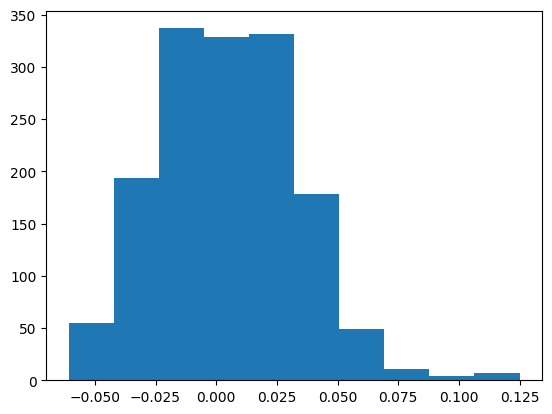

In [7]:
plt.hist(cos_sim)

torch.Size([1496])
tensor(0.0085)


(array([ 25., 147., 267., 283., 300., 269., 129.,  53.,  16.,   7.]),
 array([-0.060558  , -0.04382823, -0.02709847, -0.01036871,  0.00636105,
         0.02309082,  0.03982057,  0.05655034,  0.0732801 ,  0.09000986,
         0.10673963]),
 <BarContainer object of 10 artists>)

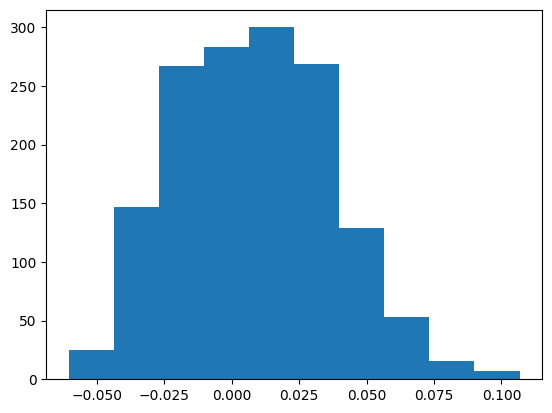

In [26]:

# cosine similarity for each example
cos_sim = F.cosine_similarity(acts_original, acts_leftpad, dim=1)

print(cos_sim.shape)   # (N,)
print(cos_sim.mean())  # average similarity
plt.figure()
plt.hist(cos_sim)